# Chapter 47 — Installation, Environmental, and Cumulative Uncertainty
### *Modern Strain Gage Technology* — Companion Notebook

**How much does a falling insulation resistance cost a quarter-bridge reading?** Water that reaches a gage installation opens a leakage path from the grid to the specimen. This notebook turns that leakage into an equivalent strain error (Eq. 47.1), checks the worst-case lumped-shunt model against a distributed-leakage network, and plots the error against the insulation-resistance thresholds practitioners use (Figure 47.1).

**What this notebook builds:**
1. **Eq. 47.1** — the leakage error bound, from the shunt relation of Chapter 29 (Eq. 29.2).
2. **The chapter's worked examples** — 350 Ω at 10,000 MΩ and at 1 MΩ; the insulation resistance at which leakage reaches 1 µε; the 10 MΩ hot-installation floor.
3. **A network check** — leakage spread along the grid to a floating specimen acts like a shunt about twelve times the measured insulation resistance, so Eq. 47.1 bounds the error.
4. **Figure 47.1** — leakage error versus insulation resistance for 120, 350, and 1,000 Ω gages.

Sources for the thresholds: Micro-Measurements TN-501 and the Model 1300 Gage Installation Tester data sheet (Doc. 2581): 20,000 MΩ expected for a laboratory installation, 10,000 MΩ minimum, 10 MΩ the lowest allowable above +150 °C; BSSM Code of Practice: 3,000 MΩ minimum.

In [1]:
# Colab: uncomment to install dependencies
# !pip install numpy matplotlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# Figures are written next to the book's Chapter 47 source so the build picks them up.
OUT_DIR = Path("../src/media/ch47")
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Eq. 47.1: leakage as a shunt on the active arm

A resistor $R_s$ in parallel with the gage lowers the arm resistance by $\Delta R/R = -R_G/(R_G+R_s)$, which a quarter bridge reads as the strain of Eq. 29.2. Taking the measured insulation resistance $R_{ins}$ as that shunt (the whole leakage lumped across the active arm, the worst case):

$$\varepsilon_{leak} = -\frac{R_G}{GF\,(R_G + R_{ins})} \approx -\frac{R_G}{GF\,R_{ins}} \qquad (47.1)$$

The approximation is exact to one part in $R_{ins}/R_G$, which is at least $10^4$ for any installation anyone would use.

In [2]:
def eps_leak_ue(R_G, GF, R_ins):
    # Equivalent strain error (microstrain) of a leakage path R_ins lumped across the active arm, Eq. 47.1.
    return -R_G / (GF * (R_G + R_ins)) * 1e6


MOHM = 1e6

# First-encounter example: 350 ohm, GF 2.00
for R_ins_mohm in (10_000, 1):
    print(f"350 ohm, GF 2.00, R_ins = {R_ins_mohm:>6,} MOhm -> {eps_leak_ue(350, 2.00, R_ins_mohm*MOHM):10.4f} ue")

# Applied example: 350 ohm, GF 2.05
GF = 2.05
R_for_1ue = 350 / (GF * 1e-6)
print(f"\nR_ins at which leakage reaches 1 ue (350 ohm, GF 2.05): {R_for_1ue/MOHM:.1f} MOhm")
print(f"R_ins at which leakage equals the Ch 45 u_c of 4.85 ue: {350/(GF*4.85e-6)/MOHM:.1f} MOhm")
print(f"Leakage at the 10 MOhm hot-installation floor: {eps_leak_ue(350, GF, 10*MOHM):.2f} ue")
print(f"Change in reading as R_ins falls 1,000 -> 10 MOhm: "
      f"{eps_leak_ue(350, GF, 10*MOHM) - eps_leak_ue(350, GF, 1000*MOHM):.2f} ue")

# A 1 MOhm shunt on one arm of a 350 ohm transducer bridge, 10 V excitation, 20 mV full scale
dV = 10 / 4 * 350 / (350 + 1e6) * 1e3   # mV, small-signal one-arm output
print(f"\n1 MOhm across one 350 ohm arm: {dV:.3f} mV = {dV/20*100:.1f}% of a 20 mV full scale")
dV1k = 10 / 4 * 1000 / (1000 + 1e6) * 1e3
print(f"1 MOhm across one 1,000 ohm arm: {dV1k:.3f} mV = {dV1k/20*100:.1f}% of a 20 mV full scale")

350 ohm, GF 2.00, R_ins = 10,000 MOhm ->    -0.0175 ue
350 ohm, GF 2.00, R_ins =      1 MOhm ->  -174.9388 ue

R_ins at which leakage reaches 1 ue (350 ohm, GF 2.05): 170.7 MOhm
R_ins at which leakage equals the Ch 45 u_c of 4.85 ue: 35.2 MOhm
Leakage at the 10 MOhm hot-installation floor: -17.07 ue
Change in reading as R_ins falls 1,000 -> 10 MOhm: -16.90 ue

1 MOhm across one 350 ohm arm: 0.875 mV = 4.4% of a 20 mV full scale
1 MOhm across one 1,000 ohm arm: 2.498 mV = 12.5% of a 20 mV full scale


## 2. Why Eq. 47.1 is a bound: distributed leakage to a floating specimen

The megohmmeter measures the parallel sum of every leakage path from the grid to the specimen. If the specimen has no other connection to the circuit, leakage current must leave the grid at one point and return at another, so the paths act in series. Below, the grid is split into $N$ series segments, each node leaks to a common floating node, and the total leakage conductance is $1/R_{ins}$. Solving the network gives the equivalent shunt across the gage.

In [3]:
def equivalent_shunt(R_G, R_ins, weights):
    # Equivalent shunt across the gage terminals for leakage to a floating node.
    # weights: fraction of the total leakage conductance 1/R_ins attached to each grid node.
    n = len(weights)                 # grid nodes 0..n-1; node n is the floating specimen
    r = R_G / (n - 1)                # series resistance between adjacent grid nodes
    G = np.zeros((n + 1, n + 1))
    for i in range(n - 1):           # grid segments
        g = 1 / r
        G[i, i] += g; G[i + 1, i + 1] += g; G[i, i + 1] -= g; G[i + 1, i] -= g
    for i, w in enumerate(weights):  # leakage to the floating node
        g = w / R_ins
        G[i, i] += g; G[n, n] += g; G[i, n] -= g; G[n, i] -= g
    # Drive node 0 at 1 V, hold node n-1 at 0 V; solve the remaining nodes.
    known = {0: 1.0, n - 1: 0.0}
    unk = [k for k in range(n + 1) if k not in known]
    A = G[np.ix_(unk, unk)]
    b = -sum(G[np.ix_(unk, [k])].ravel() * v for k, v in known.items())
    v = np.zeros(n + 1); v[0] = 1.0
    v[unk] = np.linalg.solve(A, b)
    I = (G[0] @ v)                   # current drawn from the driven terminal
    R_eff = 1.0 / I
    return 1.0 / (1.0 / R_eff - 1.0 / R_G)


R_G, R_ins = 350.0, 350.0 * 1e4
N = 401
uniform = np.full(N, 1.0 / (N - 1)); uniform[0] = uniform[-1] = 0.5 / (N - 1)   # trapezoid weights
ends = np.zeros(N); ends[0] = ends[-1] = 0.5

print(f"Leakage spread evenly along the grid : R_shunt = {equivalent_shunt(R_G, R_ins, uniform)/R_ins:6.2f} x R_ins")
print(f"Leakage split between the two tabs   : R_shunt = {equivalent_shunt(R_G, R_ins, ends)/R_ins:6.2f} x R_ins")
print("Leakage all at one tab              : no shunt at all (the floating node has no return path)")

Leakage spread evenly along the grid : R_shunt =  12.00 x R_ins
Leakage split between the two tabs   : R_shunt =   4.00 x R_ins
Leakage all at one tab              : no shunt at all (the floating node has no return path)


In [4]:
# Grounded specimen, bridge referenced to ground (P- = 0 V, P+ = V).
# Leakage R_ins from a point a fraction x along the grid (x = 0 at P+, x = 1 at S-) to ground.
def grounded_error_ue(R_G, GF, R_ins, x, V=1.0):
    a, b = R_G * x, R_G * (1 - x)          # grid split at the leakage point M
    A = np.array([[1/a + 1/b + 1/R_ins, -1/b],
                  [-1/b, 1/b + 1/R_G]])     # nodes M and S-, completion resistor R_G from S- to ground
    vm, vs = np.linalg.solve(A, np.array([V / a, 0.0]))
    dv = vs - V / 2                         # change in the S- node voltage
    return -4 * dv / (V * GF) * 1e6         # quarter-bridge equivalent strain


for x in (0.001, 0.25, 0.5, 0.75, 0.999):
    print(f"leak point x = {x:5.3f}: error = {grounded_error_ue(350, 2.0, 3.5e6, x):+7.2f} ue (positive = upscale) "
          f"(Eq. 47.1 bound {350/(2.0*3.5e6)*1e6:.2f} ue)")

leak point x = 0.001: error =   +0.10 ue (positive = upscale) (Eq. 47.1 bound 50.00 ue)
leak point x = 0.250: error =  +21.87 ue (positive = upscale) (Eq. 47.1 bound 50.00 ue)
leak point x = 0.500: error =  +37.50 ue (positive = upscale) (Eq. 47.1 bound 50.00 ue)
leak point x = 0.750: error =  +46.87 ue (positive = upscale) (Eq. 47.1 bound 50.00 ue)
leak point x = 0.999: error =  +50.00 ue (positive = upscale) (Eq. 47.1 bound 50.00 ue)


Leakage spread evenly along the grid acts like a shunt of about $12\,R_{ins}$; leakage concentrated at the two solder tabs, like $4\,R_{ins}$. A grounded specimen with a grounded bridge is the other common case: leakage from a point on the grid then loads the gage or its neighbouring arm, depending on where along the grid it occurs, and the error is again no larger than Eq. 47.1 in magnitude. Its sign differs: leakage near the output node shunts the completion arm and reads upscale (positive), where the floating case reads downscale. Eq. 47.1 bounds the magnitude to carry in a budget, and the true error is usually several times smaller.

Only the change in leakage between zeroing and reading reaches the result, $(R_G/GF)(1/R_{ins,read} - 1/R_{ins,zero})$; the cell above prints the cold-zeroed, hot-read case (1,000 MΩ at zero, 10 MΩ at reading).

## 3. Figure 47.1

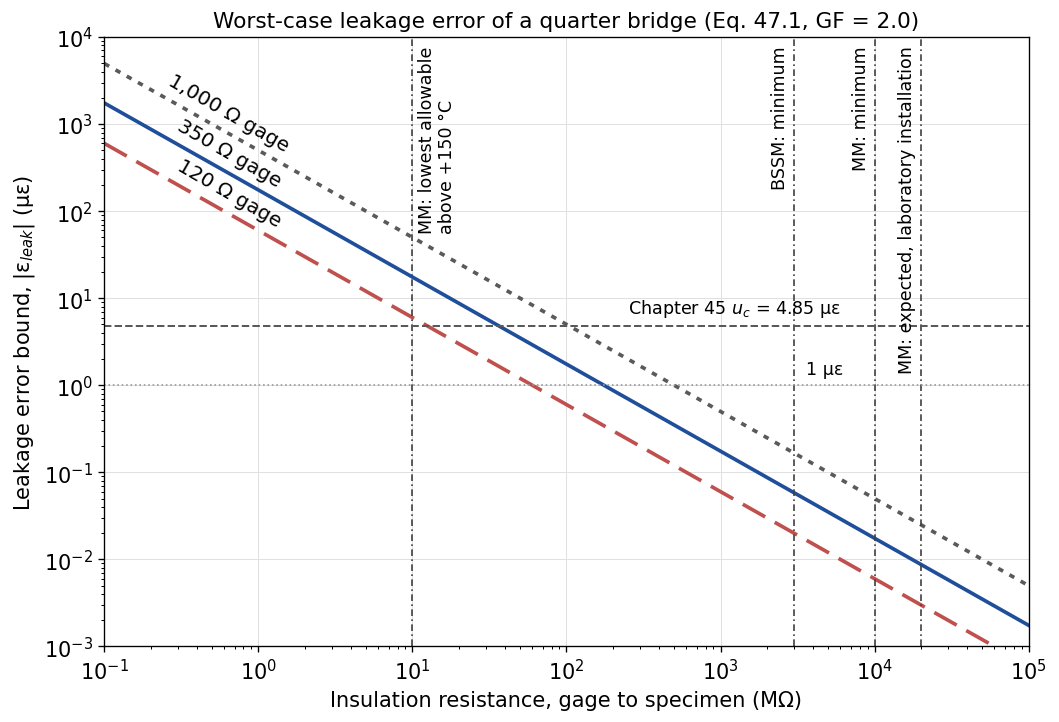

In [5]:
plt.rcParams.update({'font.size': 12.5, 'axes.titlesize': 13})
fig, ax = plt.subplots(figsize=(9, 6.2))

R_ins_mohm = np.logspace(-1, 5, 400)          # 0.1 MOhm to 100,000 MOhm
GF_PLOT = 2.0
styles = [(120,  '#c0504d', (0, (7, 3)),  '120 Ω'),
          (350,  '#1f4e9a', '-',          '350 Ω'),
          (1000, '#5a5a5a', (0, (1.5, 2)), '1,000 Ω')]
for R, color, ls, lab in styles:
    y = np.abs(eps_leak_ue(R, GF_PLOT, R_ins_mohm * MOHM))
    ax.plot(R_ins_mohm, y, color=color, lw=2.2, linestyle=ls)
    # direct label just above each line, rotated to follow its slope
    x0 = 0.6
    ax.text(x0, np.abs(eps_leak_ue(R, GF_PLOT, x0 * MOHM)) * 1.3, lab + ' gage', color='black',
            fontsize=12, ha='center', va='bottom', rotation=-30, rotation_mode='anchor')

# Thresholds (vertical) from MM TN-501 / Model 1300 data sheet and the BSSM Code of Practice,
# labeled vertically beside each line in the empty upper part of the plot.
thresholds = [(20_000, 'MM: expected, laboratory installation'),
              (10_000, 'MM: minimum'),
              (3_000,  'BSSM: minimum'),
              (10,     'MM: lowest allowable' + chr(10) + 'above +150 °C')]
for x, lab in thresholds:
    ax.axvline(x, color='0.25', lw=1.0, linestyle=(0, (4, 2, 1, 2)))
    if x == 10:   # right of its line, clear of the data
        ax.text(x * 1.08, 8e3, lab, fontsize=10.5, va='top', ha='left', rotation=90)
    else:
        ax.text(x / 1.07, 8e3, lab, fontsize=10.5, va='top', ha='right', rotation=90)

# Budget reference lines (horizontal)
ax.axhline(4.85, color='0.35', lw=1.2, linestyle='--')
ax.text(250, 4.85 * 1.2, 'Chapter 45 $u_c$ = 4.85 με', fontsize=10.5, va='bottom')
ax.axhline(1.0, color='0.6', lw=1.0, linestyle=':')
ax.text(3600, 1.0 * 1.2, '1 με', fontsize=10.5, va='bottom')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(0.1, 1e5); ax.set_ylim(1e-3, 1e4)
ax.set_xlabel('Insulation resistance, gage to specimen (MΩ)')
ax.set_ylabel('Leakage error bound, |ε$_{leak}$| (με)')
ax.set_title('Worst-case leakage error of a quarter bridge (Eq. 47.1, GF = 2.0)')
ax.grid(True, which='major', color='0.88', lw=0.6)
plt.tight_layout()
fig.savefig(OUT_DIR / 'fig47_nb1_leakage_error.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. What the figure says

At the 10,000 MΩ acceptance minimum the leakage itself costs a 350 Ω quarter bridge about 0.02 µε, three orders of magnitude below a careful budget. The leakage term reaches 1 µε only near 170 MΩ and the Chapter 45 combined standard uncertainty only near 35 MΩ. What the acceptance thresholds guard against is what comes next: a low reading means water or contamination is present, and the installation may deteriorate with time and strain (TN-501). Above +150 °C, where 10 MΩ is an accepted floor, the leakage term is 17 µε for a 350 Ω gage and belongs in the budget, evaluated from the insulation resistance measured at temperature.